In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load the preprocessed data

In [ ]:
#Import All The Necessary Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
#Import The PreProcessed Data Set

# Define the path to the preprocessed CSV file
input_path = "LungCancer_Preprocessed_DataSet.csv"

# Load the preprocessed data into a DataFrame
df_preprocessed = pd.read_csv(input_path)

# Display the shape(No of Records,Columns ) of the loaded DataFrame
print("Shape of the preprocessed DataFrame:")
print(df_preprocessed.shape)


Shape of the preprocessed DataFrame:
(100211, 36)


# Preparing features and target




In [ ]:
## Remove Survived column
X = df_preprocessed.drop(columns=['survived', 'id'])

## This represents the output variable
y = df_preprocessed['survived']

In [ ]:
#Check for class imbalance
print("Class distribution in target:")
print(y.value_counts(normalize=True))

#Split the data using a train-test split with 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Class distribution in target:
survived
0    0.779685
1    0.220315
Name: proportion, dtype: float64


# Design and Implement the Random Forest Classifier

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

#define which hyperparameters we want to tune for our model
param_dist = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__class_weight': ['balanced', None]
}

#Drop date and family_history columns before fitting
X_train_cleaned = X_train.drop(columns=['diagnosis_date', 'end_treatment_date', 'family_history'])
X_test_cleaned = X_test.drop(columns=['diagnosis_date', 'end_treatment_date', 'family_history'])

#Perform RandomizedSearchCV with limited iterations for speed
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_cleaned, y_train)

# Print Best parameters from tuning
print("Best hyperparameters from RandomizedSearchCV:")
print(random_search.best_params_)


# Through RandomizedSearchCV, we trained 10 random varieties × 5 folds = 50 fits.

# - Variety 1: Default RF (no tuning, class_weight=None)
# - Variety 2: Tuned with best parameters (from random search)
# - Variety 3: Another variant with shallower trees (e.g., max_depth=10, n_estimators=50, min_samples_split=10, class_weight='balanced')

# Variety 1: Default RF
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train_cleaned, y_train)
y_pred_default = rf_default.predict(X_test_cleaned)
y_proba_default = rf_default.predict_proba(X_test_cleaned)[:, 1]

# Variety 2: Best from RandomizedSearchCV
rf_tuned_best = random_search.best_estimator_
y_pred_tuned_best = rf_tuned_best.predict(X_test_cleaned)
y_proba_tuned_best = rf_tuned_best.predict_proba(X_test_cleaned)[:, 1]

# Variety 3: Custom variant (shallower for comparison)
rf_shallow = RandomForestClassifier(n_estimators=50, max_depth=10, min_samples_split=10, class_weight='balanced', random_state=42)
rf_shallow.fit(X_train_cleaned, y_train)
y_pred_shallow = rf_shallow.predict(X_test_cleaned)
y_proba_shallow = rf_shallow.predict_proba(X_test_cleaned)[:, 1]

Best hyperparameters from RandomizedSearchCV:
{'rf__n_estimators': 50, 'rf__min_samples_split': 5, 'rf__max_depth': 10, 'rf__class_weight': 'balanced'}


The RandomizedSearchCV method was used for parameter tuning because it’s a faster and more efficient alternative to GridSearchCV. Instead of testing every possible combination, it randomly samples from the parameter space, allowing broader exploration in less time

# Evaluation metrics


--- Default RF Metrics ---
Accuracy: 0.7725
F1 Score: 0.0185
Precision: 0.1870
Recall: 0.0097
AUC-ROC: 0.4978
Confusion Matrix:
[[15440   187]
 [ 4373    43]]


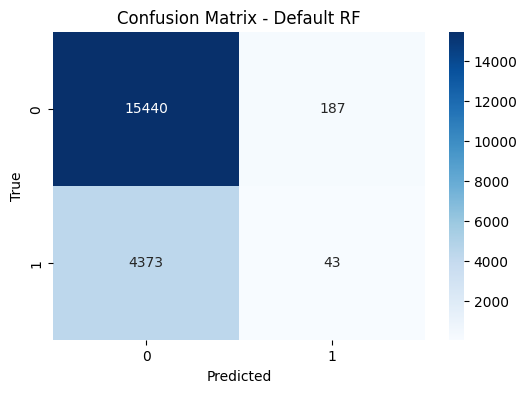


--- Tuned Best RF Metrics ---
Accuracy: 0.5911
F1 Score: 0.2746
Precision: 0.2254
Recall: 0.3512
AUC-ROC: 0.5050
Confusion Matrix:
[[10296  5331]
 [ 2865  1551]]


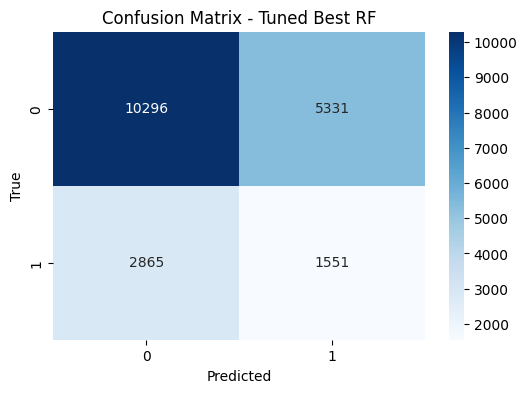


--- Shallow RF Metrics ---
Accuracy: 0.5835
F1 Score: 0.2784
Precision: 0.2251
Recall: 0.3646
AUC-ROC: 0.5047
Confusion Matrix:
[[10085  5542]
 [ 2806  1610]]


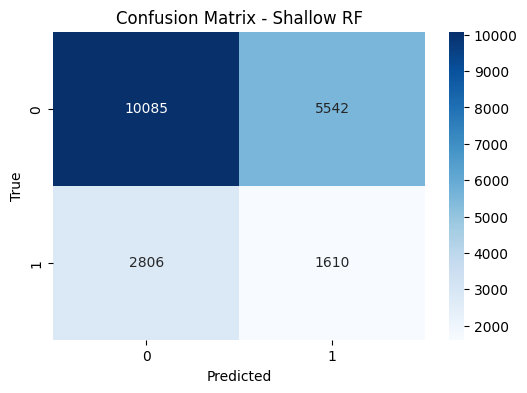

5-Fold CV F1 Scores for Best RF: [0.25798349 0.26528384 0.26171214 0.27337398 0.264326  ]
Mean CV F1: 0.2645


In [ ]:
# This is the Function to compute and print metrics
def evaluate_model(y_true, y_pred, y_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- {model_name} Metrics ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    #Generate Heatmaps to Visualize Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

#compare the different versions we got.
evaluate_model(y_test, y_pred_default, y_proba_default, "Default RF")
evaluate_model(y_test, y_pred_tuned_best, y_proba_tuned_best, "Tuned Best RF")
evaluate_model(y_test, y_pred_shallow, y_proba_shallow, "Shallow RF")

#validate the performance of the best modelusing 5 fold cross validation

# Drop date and family_history columns from the full feature set for cross-validation
X_cleaned = X.drop(columns=['diagnosis_date', 'end_treatment_date', 'family_history'])
cv_scores = cross_val_score(rf_tuned_best, X_cleaned, y, cv=5, scoring='f1')
print(f"5-Fold CV F1 Scores for Best RF: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f}")